# 🇸🇩 Sudan Climate Data Analysis (2015–2026)

## Objective  
Analyze temperature, rainfall, and climate variability trends in Sudan using NASA POWER dataset.

### Focus
- Data cleaning  
- Hot and arid climate behavior  
- Rainfall scarcity and extreme heat events  
- Climate risks and drought patterns  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

I load the NASA POWER dataset and inspect structure, columns, and basic integrity.

In [3]:
data = pd.read_csv("../Data/sudan.csv")
print(data.head(10))
data.columns

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  25.18    35.55    16.14      19.41          0.0  31.87  3.46   
1  2015    2  23.92    34.14    15.81      18.33          0.0  23.83  4.24   
2  2015    3  22.73    31.64    15.09      16.55          0.0  38.21  5.01   
3  2015    4  19.15    27.35    12.88      14.47          0.0  21.07  5.72   
4  2015    5  17.54    27.22     9.49      17.73          0.0  21.58  4.28   
5  2015    6  17.18    25.67    10.15      15.52          0.0  25.86  4.46   
6  2015    7  17.02    25.99     9.57      16.42          0.0  25.69  4.96   
7  2015    8  16.18    24.74     9.18      15.56          0.0  23.63  5.67   
8  2015    9  14.29    22.39     7.83      14.56          0.0  23.46  5.58   
9  2015   10  13.18    21.04     6.59      14.45          0.0  32.34  5.03   

   WS2M_MAX     PS  QV2M  
0      5.12  96.54  6.08  
1      5.10  96.67  4.31  
2      6.24  96.77  6.42  
3      6.96  96.93  3.06  
4     

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='object')

In [4]:
print(data.shape)
print(data.info())

(4108, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB
None


## 2. Data Cleaning

I handle missing values, convert date formats, and remove duplicates.

NASA uses -999 as missing values, which we convert to NaN.

In [5]:
data.replace(-999, np.nan, inplace=True)
print(data.isna().sum())
print(data.describe())
print(data.min())

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64
              YEAR          DOY          T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean   2020.131451   180.121227    28.759007    36.773914    21.508510   
std       3.248907   106.294767     4.681305     4.400065     5.091142   
min    2015.000000     1.000000    13.180000    21.040000     5.930000   
25%    2017.000000    86.000000    25.560000    33.730000    17.497500   
50%    2020.000000   179.000000    29.160000    37.020000    22.890000   
75%    2023.000000   272.000000    32.510000    40.330000    25.430000   
max    2026.000000   366.000000    37.990000    45.960000    32.170000   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.0000

## 3. Date Processing

I convert YEAR and DOY into a proper datetime column for time-series analysis.

In [13]:
data["Month"] = pd.to_datetime(data["YEAR"].astype(str) + "-" + data["DOY"].astype(str), format="%Y-%j").dt.month

monthly_temp = data.groupby("Month")["T2M"].mean()
duplicates = data.duplicated().sum()
print("Duplicates:", duplicates)
data = data.drop_duplicates()
missing = data.isna().mean() * 100
print(missing)

Duplicates: 0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Month          0.0
dtype: float64


In [14]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(data[cols].apply(zscore))
outliers = (z_scores > 3).sum()

print(outliers)

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


## 4. Temperature Trends

I analyze monthly average temperature to identify seasonal patterns and warming trends.

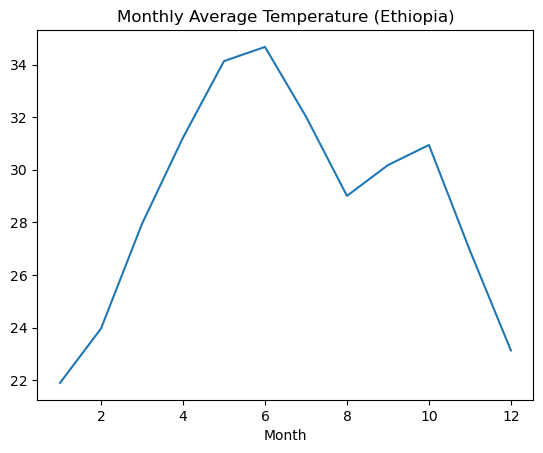

In [8]:
monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.show()

## 5. Rainfall Patterns

I examine precipitation distribution to understand wet and dry seasons.

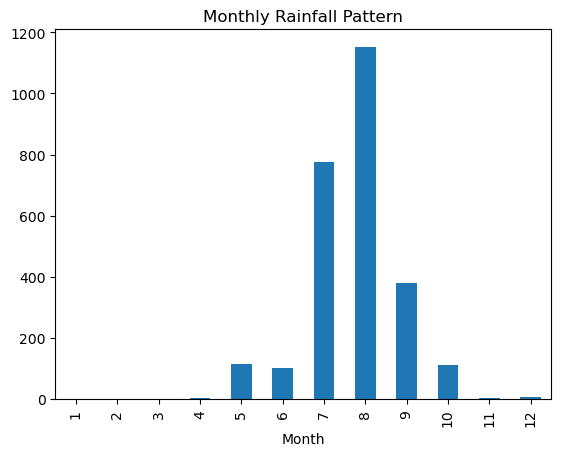

In [10]:
monthly_rain = data.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall Pattern")
plt.show()

## 6. Climate Variable Relationships

I examine correlations between temperature, rainfall, humidity, and wind.

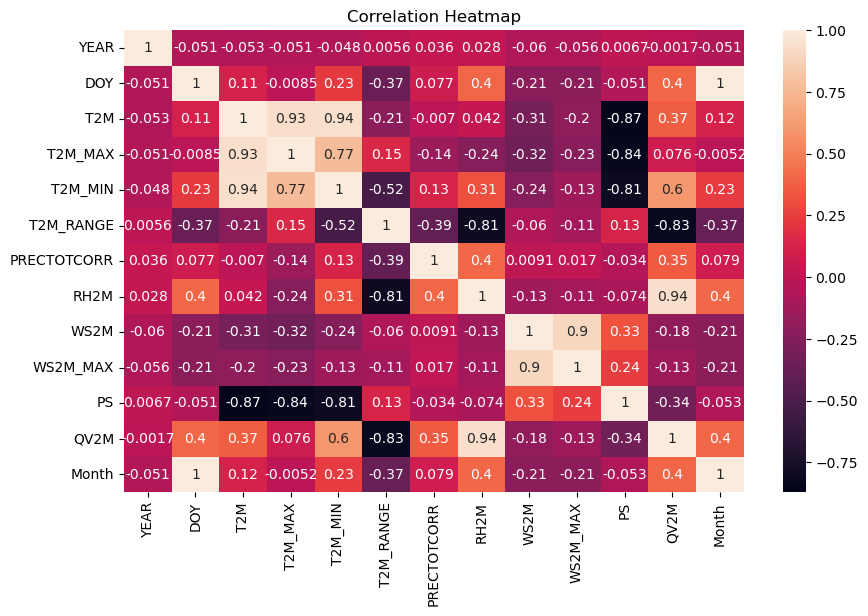

In [11]:

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()